In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F #moves data forward in function
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cuda


In [2]:
# Create Model Class that inherits nn.Module
class Model(nn.Module): #class = neural network, doing nn.Module means it is able to use all of these features
    #input layer with 4 features --> hidden layer 1 --> hidden layer 2 --> single output
    def __init__(self, in_features=4, h1=64, h2=32, out_features=1): #creates layers
        super().__init__() #sets up parent class initialisation of nn.Module
        self.fc1 = nn.Linear(in_features, h1) #creating hidden layer 1 here with in_features number of inputs and h1 number of outputs
        self.fc2 = nn.Linear(h1,h2) 
        self.out = nn.Linear(h2,out_features) #even for nonlinear datasets, nn.Linear is the choice here, just need to add activation later
    def forward(self,x): #function which moves data through network, x is the variable here which gets moved through
        x = F.relu(self.fc1(x)) #Activation ReLU function (Rectified Linear Unit)
        x = F.relu(self.fc2(x)) 
        x = self.out(x) #No activation function on final layer
        return x

In [3]:
import pandas as pd
import os
data_path_phi_1 = r"C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 2D - Different phi\phi1"
all_data_phi_1 = []

for i in range(10000, 10200):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path_phi_1, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows

    #read field data
    for t in range(2, 12):  # time snapshots (14 with active chemistry)
        fields_df = pd.read_csv(os.path.join(data_path_phi_1, f'fields_{i}_{t}'),
                               sep=r'\s+', skiprows=5, header=None,
                               names=['density', 'u', 'v', 'vorticity', 'temperature',
                                      'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4',
                                      'ms5', 'ms6', 'ms7', 'ms8', 'ms9','c','dc/dx','dc/dy'])
        
        combined_phi_1 = pd.concat([nodes_df, fields_df], axis=1)
        combined_phi_1['processor'] = i
        combined_phi_1['timestep'] = t 
        combined_phi_1['phi'] = 1
        all_data_phi_1.append(combined_phi_1)

# Final DataFrame with everything
df_phi_1 = pd.concat(all_data_phi_1, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed

In [4]:

data_path_phi_05 = r"C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 2D - Different phi\phi0.5"
all_data_phi_05 = []

for i in range(10000, 10200):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path_phi_05, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows

    #read field data
    for t in range(2, 12): 
        fields_df = pd.read_csv(os.path.join(data_path_phi_05, f'fields_{i}_{t}'),
                               sep=r'\s+', skiprows=5, header=None,
                               names=['density', 'u', 'v', 'vorticity', 'temperature',
                                      'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4',
                                      'ms5', 'ms6', 'ms7', 'ms8', 'ms9','c','dc/dx','dc/dy'])
        
        combined_phi_05 = pd.concat([nodes_df, fields_df], axis=1)
        combined_phi_05['processor'] = i
        combined_phi_05['timestep'] = t 
        combined_phi_05['phi'] = 0.5
        all_data_phi_05.append(combined_phi_05)

# Final DataFrame with everything
df_phi_05 = pd.concat(all_data_phi_05, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed

In [5]:

data_path_phi_04 = r"C:\Users\Jamie Harvey\OneDrive - The University of Manchester\Desktop\y3 individual project\Sample Data 2D - Different phi\phi0.4"
all_data_phi_04 = []

for i in range(10000, 10200):
    # Read nodes
    nodes_df = pd.read_csv(os.path.join(data_path_phi_04, f'nodes_{i}'),
                          sep=r'\s+', skiprows=1,
                          names=['dummy1', 'x', 'y', 'dx', 'dummy2', 'dummy3', 'dummy4']) #path join searches for file name in folder, skip header rows

    #read field data
    for t in range(2, 12): 
        fields_df = pd.read_csv(os.path.join(data_path_phi_04, f'fields_{i}_{t}'),
                               sep=r'\s+', skiprows=5, header=None,
                               names=['density', 'u', 'v', 'vorticity', 'temperature',
                                      'pressure', 'HRR', 'ms1', 'ms2', 'ms3', 'ms4',
                                      'ms5', 'ms6', 'ms7', 'ms8', 'ms9','c','dc/dx','dc/dy'])
        
        combined_phi_04 = pd.concat([nodes_df, fields_df], axis=1)
        combined_phi_04['processor'] = i
        combined_phi_04['timestep'] = t 
        combined_phi_04['phi'] = 0.4
        all_data_phi_04.append(combined_phi_04)

# Final DataFrame with everything
df_phi_04 = pd.concat(all_data_phi_04, ignore_index=True) #vertical merger of all processor data into a single data frame, pd.concat default is vertical so no spec needed

In [6]:
df = pd.concat([df_phi_1, df_phi_05, df_phi_04], ignore_index=True)
print(f"Final shape: {df.shape}")
df

Final shape: (4092150, 29)


,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms6,ms7,ms8,ms9,c,dc/dx,dc/dy,processor,timestep,phi
0,2328,-1.921960,0.447463,0.006,0.015876,0.015876,999,0.845151,1.646973,-0.001170,...,-1.706650e-27,5.670292e-26,-1.045044e-41,0.745187,0.027933,8.301732e-06,7.146258e-06,10000,2,1.0
1,4233,-1.853835,0.447651,0.006,0.016200,0.016200,999,0.845138,1.639752,-0.000348,...,-3.017999e-27,1.032569e-25,1.862424e-38,0.745187,0.027933,4.862421e-07,1.966991e-06,10000,2,1.0
2,6482,-1.775918,0.447719,0.006,0.015247,0.015247,999,0.845127,1.631904,-0.000008,...,-3.898029e-27,1.339446e-25,9.291338e-38,0.745187,0.027933,7.598729e-06,-1.021200e-05,10000,2,1.0
3,6125,-1.787625,0.447738,0.006,0.015876,0.015876,999,0.845127,1.632888,0.000087,...,-3.824818e-27,1.329545e-25,-2.506693e-37,0.745187,0.027933,3.392028e-06,-1.156857e-05,10000,2,1.0
4,4433,-1.845683,0.447841,0.006,0.016200,0.016200,999,0.845137,1.638664,-0.000313,...,-3.151244e-27,1.087707e-25,-6.994422e-39,0.745187,0.027933,6.917993e-06,5.534105e-07,10000,2,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4092145,132345,1.860804,0.447907,0.006,0.015876,0.015876,999,0.221229,2.651287,-0.119462,...,1.509498e-08,3.319678e-07,1.283540e-07,0.759643,0.999966,3.832323e-03,-1.228482e-03,10199,11,0.4
4092146,132187,1.853980,0.448018,0.006,0.015876,0.015876,999,0.221300,2.652735,-0.120168,...,1.527610e-08,3.343729e-07,1.296361e-07,0.759620,0.999966,3.900759e-03,-1.225147e-03,10199,11,0.4
4092147,131611,1.834425,0.448094,0.006,0.013507,0.013507,999,0.221507,2.656109,-0.122138,...,1.581590e-08,3.415505e-07,1.334372e-07,0.759553,0.999965,4.131519e-03,-1.220285e-03,10199,11,0.4
4092148,130933,1.810192,0.448103,0.006,0.015876,0.015876,999,0.221765,2.659598,-0.124478,...,1.653922e-08,3.511391e-07,1.384403e-07,0.759468,0.999964,4.498885e-03,-1.211088e-03,10199,11,0.4


In [7]:
# Step 1: Initial filter to reaction zone
df_filtered = df[df['c'].between(0.1, 0.9)]

# Step 2: Raise lower c bound for lean flames
mask_04 = (df_filtered['phi'] == 0.4) & (df_filtered['c'] < 0.55)
mask_05 = (df_filtered['phi'] == 0.5) & (df_filtered['c'] < 0.2)
combined_mask = mask_04 | mask_05  # remove rows matching EITHER condition
df_filtered = df_filtered[~combined_mask]

# Step 3: Remove negative HRR
df_filtered = df_filtered[df_filtered['HRR'] >= 0]

# Step 4: HRR floor (keep this generous)
df_filtered = df_filtered[df_filtered['HRR'] > 1]
df_filtered

,dummy1,x,y,dx,dummy2,dummy3,dummy4,density,u,v,...,ms6,ms7,ms8,ms9,c,dc/dx,dc/dy,processor,timestep,phi
74775,13603,-1.519682,0.448858,0.006,0.016200,0.016200,999,0.643156,-0.253303,-0.304697,...,-0.000054,0.000269,0.000180,0.742091,0.109531,921.163984,445.096312,10010,11,1.0
74818,13614,-1.519955,0.455250,0.006,0.015876,0.015876,999,0.582033,0.068637,-0.036908,...,-0.000030,0.000315,0.000175,0.741219,0.135701,1160.304897,451.646363,10010,11,1.0
74841,13521,-1.523765,0.459508,0.006,0.015876,0.015876,999,0.631079,0.274671,-0.043611,...,-0.000051,0.000277,0.000174,0.742057,0.111317,952.444145,302.023629,10010,11,1.0
74857,13685,-1.517704,0.461478,0.006,0.016200,0.016200,999,0.477295,0.894308,0.184728,...,0.000054,0.000374,0.000156,0.739363,0.198402,1723.772945,518.067321,10010,11,1.0
74890,13578,-1.520274,0.466651,0.006,0.015876,0.015876,999,0.505020,1.008496,0.012292,...,0.000021,0.000366,0.000161,0.739841,0.178316,1567.556890,347.762104,10010,11,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871428,112151,1.142096,0.234366,0.006,0.011965,0.011965,999,0.366592,2.142943,0.549104,...,0.000012,0.000147,0.000035,0.746029,0.897776,42.914372,463.623025,10167,9,0.4
3871429,111827,1.129829,0.234383,0.006,0.013507,0.013507,999,0.362078,2.094696,0.558934,...,0.000015,0.000146,0.000033,0.746586,0.895361,-0.640882,487.852362,10167,9,0.4
3876989,109415,1.043910,0.248124,0.006,0.015247,0.015247,999,0.315882,1.978334,0.260531,...,0.000042,0.000107,0.000015,0.751531,0.885574,120.415158,593.660677,10168,8,0.4
3876997,109245,1.037041,0.250039,0.006,0.016200,0.016200,999,0.309972,1.998348,0.309634,...,0.000048,0.000102,0.000014,0.752014,0.888173,137.337247,600.965836,10168,8,0.4


In [8]:
#step 2 - specifying variables of interest
#For this basic model, 6 inputs, 1 output
model_variables = ['c','density','temperature','phi','HRR']
model_data = df_filtered[model_variables]

print(model_data)

X=model_data[['c','density','temperature','phi']].values
y=model_data['HRR'].values

                c   density  temperature  phi           HRR
74775    0.109531  0.643156   399.912387  1.0  3.828561e+08
74818    0.135701  0.582033   443.961045  1.0  6.409277e+08
74841    0.111317  0.631079   407.581074  1.0  3.971411e+08
74857    0.198402  0.477295   547.322727  1.0  6.544236e+09
74890    0.178316  0.505020   515.575997  1.0  3.402201e+09
...           ...       ...          ...  ...           ...
3871428  0.897776  0.366592   886.664123  0.4  4.154385e+08
3871429  0.895361  0.362078   896.880155  0.4  4.686170e+08
3876989  0.885574  0.315882  1019.384686  0.4  7.726946e+08
3876997  0.888173  0.309972  1038.031745  0.4  8.292324e+08
3877022  0.895618  0.300571  1069.815322  0.4  8.694824e+08

[125678 rows x 5 columns]


In [9]:
from sklearn.model_selection import train_test_split
phi_col = 3

X_train_unscaled, X_unseen_unscaled, y_train_unscaled, y_unseen_unscaled = train_test_split(X, y, test_size=0.2, random_state=10, stratify=model_data['phi'])

X_test_unscaled, X_val_unscaled, y_test_unscaled, y_val_unscaled = train_test_split(X_unseen_unscaled, y_unseen_unscaled, test_size=0.5, random_state=10,stratify=X_unseen_unscaled[:, phi_col])

#scale data
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train_unscaled) #apply normalisation
X_val = scaler_X.transform(X_val_unscaled)   
X_test = scaler_X.transform(X_test_unscaled)        

y_train_log = np.log1p(np.abs(y_train_unscaled))
y_val_log = np.log1p(np.abs(y_val_unscaled))
y_test_log = np.log1p(np.abs(y_test_unscaled))    
y_train = scaler_y.fit_transform(y_train_log.reshape(-1, 1))
y_val = scaler_y.transform(y_val_log.reshape(-1, 1))
y_test = scaler_y.transform(y_test_log.reshape(-1, 1))   

#convert numpy arrays into tensors for use in PyTorch
X_train = torch.FloatTensor(X_train).to(device) #for floats
X_val = torch.FloatTensor(X_val).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_train = torch.FloatTensor(y_train).view(-1,1).to(device) #reshape
y_val = torch.FloatTensor(y_val).view(-1,1).to(device)
y_test = torch.FloatTensor(y_test).view(-1,1).to(device) #.to(device) moves to GPU 

In [10]:
#batch training
from torch.utils.data import DataLoader, TensorDataset
batch_size=32768
dataset=TensorDataset(X_train,y_train) 
train_loader=DataLoader(dataset,batch_size=batch_size,shuffle=True)#shuffle improves generalisation performance

In [11]:
torch.manual_seed(10)
model=Model().to(device)
criterion = nn.MSELoss() #Mean Squared Error for regression
optimiser = torch.optim.Adam(model.parameters(),lr=0.001) #choose optimiser and learning rate, model parameters are the layers

In [12]:
from codecarbon import EmissionsTracker #carbon emission tracker
import time

tracker = EmissionsTracker()
tracker.start()
start_training=time.time()

[codecarbon WARNING @ 17:32:23] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:32:24] [setup] RAM Tracking...
[codecarbon INFO @ 17:32:24] [setup] CPU Tracking...
[codecarbon WARNING @ 17:32:25] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 17:32:25] CPU Model on constant consumption mode: 12th Gen Intel(R) Core(TM) i7-12700H
[codecarbon WARNING @ 17:32:25] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 17:32:25] [setup] GPU Tracking...
[codecarbon INFO @ 17:32:25] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 17:32:25] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 17:32:25] >>> Tracker's metadata:
[code

In [13]:
epochs=800
train_losses=[] #list which will be added to
val_losses=[]

# Early stopping setup
best_val_loss = float('inf')
patience_counter = 0
patience = 30
min_improvement = 0.02  # 2% minimum improvement
for i in range(epochs):
    model.train() #training mode
    batch_losses=[]
    for X_batch,y_batch in train_loader:
        optimiser.zero_grad() #resets gradient calculation (neccesary)
        #go forward and predict
        y_pred=model.forward(X_batch) #get predicted results
        #Measure loss
        loss = criterion(y_pred,y_batch)
        #Back propagation (fine tuning of neuron parameters)
        loss.backward() #works out gradient for each weight (how much each weight contributed to error)
        optimiser.step() #gradient descent to update weight based on optimiser (optimiser determines how much to change weight by)
        batch_losses.append(loss.item())
        
    train_loss=np.mean(batch_losses)
    train_losses.append(train_loss)

    #validation
    model.eval()  # evaluation mode
    with torch.no_grad():  # No gradient computation for validation
        y_val_pred = model.forward(X_val)
        val_loss = criterion(y_val_pred, y_val)
        val_losses.append(val_loss.detach().cpu().numpy())

    # Early stopping check
    if val_loss < best_val_loss * (1 - min_improvement):
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {i}, best val loss: {best_val_loss:.5f}")
        break
        
    #print every 50 epochs
    if i % 5 == 0: #% operator gives remainder 
        print(f'Epoch:{i}, Training loss: {train_loss}, Validation Loss: {val_loss}')

model.load_state_dict(torch.load('best_model.pt',weights_only=True))
print("Best model loaded")

Epoch:0, Training loss: 1.016140729188919, Validation Loss: 0.933756411075592
Epoch:5, Training loss: 0.5176230072975159, Validation Loss: 0.48460882902145386


[codecarbon INFO @ 17:32:45] Energy consumed for RAM : 0.000089 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:32:45] Delta energy consumed for CPU with cpu_load : 0.000020 kWh, power : 4.563273090600001 W
[codecarbon INFO @ 17:32:46] Energy consumed for All CPU : 0.000020 kWh
[codecarbon INFO @ 17:32:46] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 17:32:46] Energy consumed for all GPUs : 0.000132 kWh. Total GPU Power : 28.350566592964583 W
[codecarbon INFO @ 17:32:46] 0.000241 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:10, Training loss: 0.280293844640255, Validation Loss: 0.2553846836090088
Epoch:15, Training loss: 0.13067147508263588, Validation Loss: 0.11948666721582413


[codecarbon INFO @ 17:33:00] Energy consumed for RAM : 0.000168 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:33:01] Delta energy consumed for CPU with cpu_load : 0.000019 kWh, power : 4.7793546603 W
[codecarbon INFO @ 17:33:01] Energy consumed for All CPU : 0.000039 kWh
[codecarbon INFO @ 17:33:01] Energy consumed for all GPUs : 0.000219 kWh. Total GPU Power : 20.970881256873195 W
[codecarbon INFO @ 17:33:01] 0.000427 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:20, Training loss: 0.07598302513360977, Validation Loss: 0.06996359676122665
Epoch:25, Training loss: 0.0571527061983943, Validation Loss: 0.055208854377269745


...

Epoch:165, Training loss: 0.03326775133609772, Validation Loss: 0.032534342259168625
Epoch:170, Training loss: 0.0350865563377738, Validation Loss: 0.0326245091855526


[codecarbon INFO @ 17:37:31] Energy consumed for RAM : 0.001609 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:37:32] Delta energy consumed for CPU with cpu_load : 0.000019 kWh, power : 4.630239523928572 W
[codecarbon INFO @ 17:37:32] Energy consumed for All CPU : 0.000386 kWh
[codecarbon INFO @ 17:37:32] Energy consumed for all GPUs : 0.001956 kWh. Total GPU Power : 21.12322412066813 W
[codecarbon INFO @ 17:37:32] 0.003952 kWh of electricity and 0.000000 L of water were used since the beginning.


Epoch:175, Training loss: 0.03177140513435006, Validation Loss: 0.03238806501030922
Epoch:180, Training loss: 0.03208957239985466, Validation Loss: 0.03238597884774208


[codecarbon INFO @ 17:37:46] Energy consumed for RAM : 0.001689 kWh. RAM Power : 20.0 W
[codecarbon INFO @ 17:37:47] Delta energy consumed for CPU with cpu_load : 0.000018 kWh, power : 4.5785977911 W
[codecarbon INFO @ 17:37:47] Energy consumed for All CPU : 0.000404 kWh
[codecarbon INFO @ 17:37:47] Energy consumed for all GPUs : 0.002046 kWh. Total GPU Power : 21.66338622483518 W
[codecarbon INFO @ 17:37:47] 0.004139 kWh of electricity and 0.000000 L of water were used since the beginning.


Early stopping at epoch 184, best val loss: 0.03281
Best model loaded


In [14]:
training_time=time.time()-start_training
print(f"Training time: {training_time} secs")

training_emissions=tracker.stop()
print(f"Training Emissions: {training_emissions} kg CO2")

[codecarbon INFO @ 17:37:49] Energy consumed for RAM : 0.001703 kWh. RAM Power : 20.0 W


Training time: 319.3909614086151 secs


[codecarbon INFO @ 17:37:50] Delta energy consumed for CPU with cpu_load : 0.000003 kWh, power : 4.555994763375001 W
[codecarbon INFO @ 17:37:50] Energy consumed for All CPU : 0.000407 kWh
[codecarbon INFO @ 17:37:50] Energy consumed for all GPUs : 0.002065 kWh. Total GPU Power : 23.194261152245986 W
[codecarbon INFO @ 17:37:50] 0.004176 kWh of electricity and 0.000000 L of water were used since the beginning.


Training Emissions: 0.000992182321125002 kg CO2


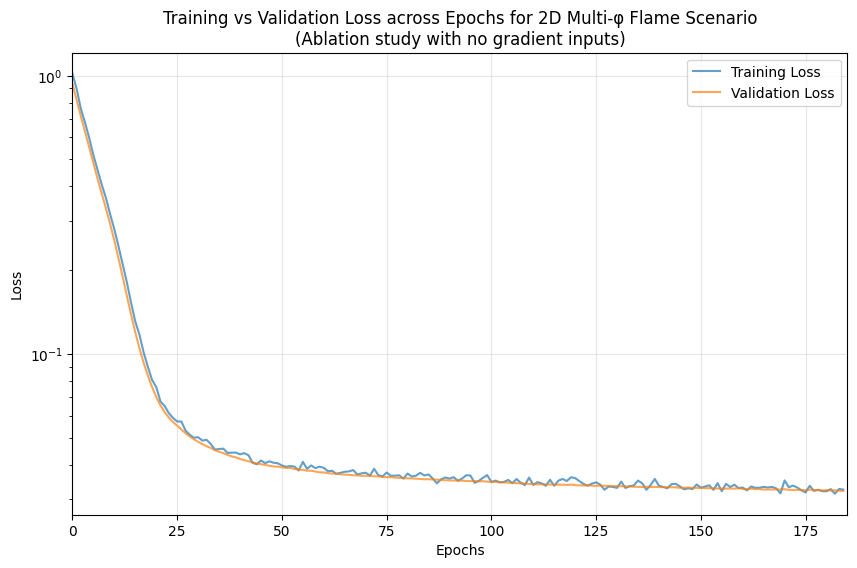

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', alpha=0.7)
plt.plot(val_losses, label='Validation Loss', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xlim(0,len(train_losses))
plt.title('Training vs Validation Loss across Epochs for 2D Multi-φ Flame Scenario\n(Ablation study with no gradient inputs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
#Evaluate Model
with torch.no_grad():
    y_pred_scaled = model(X_test)
    
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled.cpu().numpy().reshape(-1, 1))
    y_test_log = scaler_y.inverse_transform(y_test.cpu().numpy().reshape(-1, 1))

    y_pred_actual = np.sign(y_pred_log) * np.expm1(np.abs(y_pred_log))
    y_test_actual = np.sign(y_test_log) * np.expm1(np.abs(y_test_log))

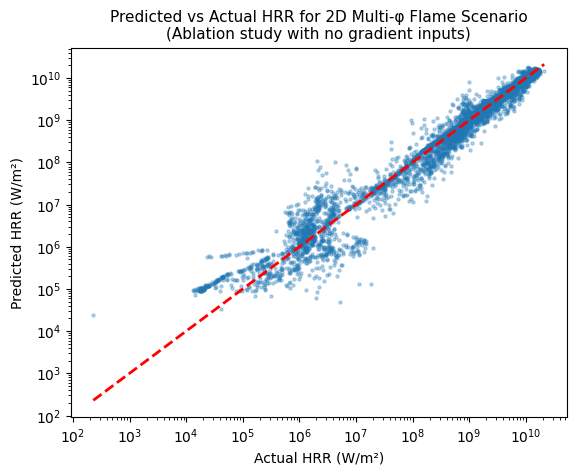

In [23]:
y_pred_np = y_pred_actual.flatten()
y_test_np = y_test_actual.flatten()

plt.scatter(y_test_np,y_pred_np,alpha=0.3, s=5)
plt.title("Predicted vs Actual HRR for 2D Multi-φ Flame Scenario\n(Ablation study with no gradient inputs)", fontsize=11)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Actual HRR (W/m²)')
plt.ylabel('Predicted HRR (W/m²)')
plt.plot([y_test_np.min(), y_test_np.max()],   # x-coordinates (start, end)
         [y_test_np.min(), y_test_np.max()],   # y-coordinates (start, end)
         'r--', lw=2)
plt.show()

In [18]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

r2 = r2_score(y_test_np, y_pred_np)
mae = mean_absolute_error(y_test_np, y_pred_np)
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_np))
mape = mean_absolute_percentage_error(y_test_actual, y_pred_actual) * 100
nmse = mean_squared_error(y_test_np, y_pred_np)/np.var(y_test_np)

#new metric - normalised MSE


print(f"\nR² Score: {r2:.4f}")
print(f"MAE:      {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")  
print(f"NMSE: {nmse:.5f}") 


R² Score: 0.9721
MAE:      287711520.00
RMSE:     656290160.82
MAPE: 28.36%
NMSE: 0.02795


In [19]:
phi_col_test = X_test_unscaled[:, 3]

for phi in [0.4, 0.5, 1.0]:
    mask = phi_col_test == phi
    r2_phi = r2_score(y_test_np[mask], y_pred_np[mask])
    mape_phi = mean_absolute_percentage_error(
                y_test_np[mask], y_pred_np[mask]) * 100
    nmse_phi = mean_squared_error(
                y_test_np[mask], y_pred_np[mask]) / np.var(y_test_np[mask])
    print(f"φ={phi}: R²={r2_phi:.4f}, MAPE={mape_phi:.2f}%, "
          f"NMSE={nmse_phi:.4f}, n={mask.sum()}")

φ=0.4: R²=0.9356, MAPE=76.59%, NMSE=0.0644, n=1903
φ=0.5: R²=0.9059, MAPE=67.44%, NMSE=0.0941, n=1959
φ=1.0: R²=0.9699, MAPE=9.02%, NMSE=0.0301, n=8706
